<a href="https://colab.research.google.com/github/TamirPalay/DI_Exercises/blob/main/week10/day3-4/Xp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Guided Student Notebook

This guided notebook follows the **exact exercise on the platform**. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear only for key concepts to support intuition and transfer to other AI topics.



## Reference from the exercise

**What you will learn**  
- The differences between traditional machine learning and deep learning.
- The structure and working of artificial neural networks. How to generate, visualize, and analyze datasets with noise.
- Techniques for fitting polynomial regression models and understanding overfitting.
- The importance of cross-validation in model selection.

**What you will create**  
- A comparative table of traditional machine learning vs deep learning.
- A simple ANN diagram with labeled components.
- A noisy dataset visualized with a scatter plot.
- Polynomial regression models of varying degrees.
- A cross-validation analysis to select an optimal polynomial degree.


## 🌟 Exercise 1: Deep Learning vs Traditional Machine Learning

**As stated in the exercise**  
Objective. Understand the differences between traditional machine learning and deep learning.  
Instructions. Create a table comparing Feature Engineering, Data Processing, Scalability, Pattern Discovery, and Computational Requirements. Identify one real world problem where traditional ML is better, and one where deep learning is better. Write a short paragraph explaining why deep learning has an advantage in unstructured data processing.

**Guidance**  
Use a markdown table for the comparison, keep wording concise and concrete, then write two short examples and one paragraph in full sentences.

**To-Do:** Complete the comparison table below by filling in each cell with your own wording.


| Aspect | Traditional ML | Deep Learning |
|:--|:--|:--|
| Feature Engineering | Manual — a person designs and selects the features the model sees | Automatic — the network learns its own features directly from raw data |
| Data Processing | Works well with small, structured, tabular data | Needs large volumes of data (structured or unstructured) to perform well |
| Scalability | Performance plateaus as data grows; adding more data gives diminishing returns | Performance tends to keep improving as data and model size scale up |
| Pattern Discovery | Finds patterns within the features it's given | Discovers hierarchical patterns on its own, from low-level to high-level |
| Computational Requirements | Low — runs fine on a CPU, trains in seconds to minutes | High — usually needs a GPU/TPU and much longer training times |


**To-Do answer**

- **Better suited to traditional ML:** Predicting house prices from a small structured dataset (square footage, number of rooms, location, age). The features are already meaningful and well-defined, so a model like linear regression or a random forest can find the relationship efficiently without needing huge amounts of data.
- **Better suited to deep learning:** Classifying objects in photographs (e.g. cats vs dogs vs cars). Raw pixel data has no obvious hand-craftable features, and a CNN can learn the relevant visual patterns directly from thousands of labeled images.


**To-Do answer**

Deep learning has an advantage on unstructured data (images, audio, text) because it performs **representation learning**: instead of relying on a person to hand-design features, the network learns directly from raw pixels, waveforms, or tokens. Early layers pick up simple patterns such as edges or word co-occurrences, and deeper layers combine these into increasingly abstract, **hierarchical features** such as shapes, objects, or semantic meaning. This layered composition lets the model capture complex, nonlinear structure that would be extremely difficult to engineer by hand. Because the feature extraction and the prediction are learned jointly, the whole pipeline can be optimized end-to-end for the task at hand.


## 🌟 Exercise 2: Artificial Neural Networks (ANNs)

**As stated in the exercise**  
Objective. Identify and understand the key components of an ANN.  
Instructions. Draw or use a diagram tool to create an ANN with an input layer of 3 neurons, one hidden layer of 4 neurons, and an output layer of 2 neurons. Label neurons, weights, biases, activation function, and layers. Write a short description of how information flows through the network.

**Guidance**  
A clear schematic is preferred. Ensure every requested label appears exactly once and is readable.



**To-Do answer**

Each of the 3 input neurons passes a raw feature value into the hidden layer. Every hidden neuron computes a **weighted sum** of all three inputs (each input multiplied by its own weight) and adds a **bias** term. This weighted sum is then passed through a nonlinear **activation function** (e.g. ReLU), which produces the hidden neuron's output. The 4 hidden neuron outputs are then combined, again via weights and biases, and passed through activation functions to produce the 2 output neurons, which represent the network's final prediction.


**Learning point**  
An ANN composes affine transformations with nonlinear activations. The affine part mixes features through weights and biases. The nonlinearity enables modeling of complex decision boundaries.


## 🌟 Exercise 3: Creating the Dataset and Visualizing the Data

**As stated in the exercise**  
Objective. Generate a dataset with noise and visualize it.  
Instructions. Import numpy, matplotlib.pyplot, and mean_squared_error from sklearn.metrics. Create 20 points using \(y = -x^2\) with Gaussian noise \(\mathcal{N}(0, 0.05)\). Plot the points with a scatter plot. Split into a training set with the first 12 points and a test set with the last 8 points.


In [1]:
# PREFILLED: just execute
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

np.random.seed(0)
x = np.arange(-1, 1, 0.1)  # 20 points from -1 to <1 step 0.1
print("x shape:", x.shape)

x shape: (20,)


In [2]:
# To-Do: generate y with noise using np.random.normal()
y = -x**2 + np.random.normal(0, 0.05, size=x.shape)
print("y shape:", y.shape)


y shape: (20,)


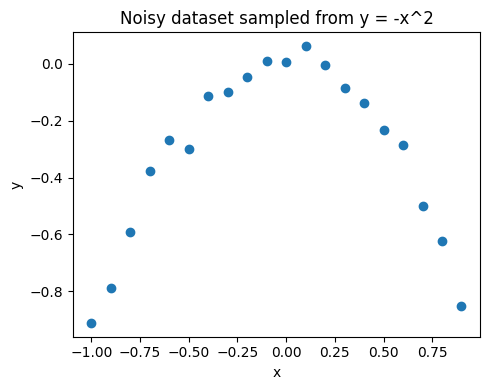

In [3]:
# PREFILLED: just execute (scatter plot of the dataset)
plt.figure(figsize=(5,4))
plt.scatter(x, y)
plt.title("Noisy dataset sampled from y = -x^2")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

In [4]:
# To-Do: split into train (first 12 points) and test (last 8 points)
x_train, y_train = x[:12], y[:12]
x_test,  y_test  = x[12:], y[12:]
print("train sizes:", x_train.shape, y_train.shape, "test sizes:", x_test.shape, y_test.shape)


train sizes: (12,) (12,) test sizes: (8,) (8,)


**Learning point**  
Visualizing noisy data helps separate signal from noise. Splitting into train and test allows you to detect when a model overfits noise instead of learning the underlying pattern.


## 🌟 Exercise 4: Fitting Polynomial Models of Different Degrees

**As stated in the exercise**  
Objective: Fit polynomial models of varying degrees and observe overfitting.  

Instructions: Define `polynomial_fit(degree)` that returns the fitted polynomial coefficients from training data. Define `plot_polyfit(degree)` that draws the training set, the test set, and the fitted polynomial curve. Visualize fits for degrees 1, 7, and 11. Observe behavior on training and test sets as degree increases.


In [5]:
# To-Do: implement polynomial_fit
# Hints: use np.polyfit() to get coefficients, and np.poly1d for a callable polynomial
def polynomial_fit(degree: int):
    coeffs = np.polyfit(x_train, y_train, degree)
    return np.poly1d(coeffs)


In [6]:
# To-Do: implement plot_polyfit
def plot_polyfit(degree: int):
    # 1) fit
    poly = polynomial_fit(degree)

    # 2) create a dense linspace over x range
    x_dense = np.linspace(x.min(), x.max(), 200)

    # 3) evaluate fitted polynomial
    y_dense = poly(x_dense)

    # 4) scatter train and test, and plot curve
    plt.figure(figsize=(5, 4))
    plt.scatter(x_train, y_train, label="train", color="tab:blue")
    plt.scatter(x_test, y_test, label="test", color="tab:orange")
    plt.plot(x_dense, y_dense, label=f"degree {degree} fit", color="tab:green")
    plt.title(f"Polynomial fit (degree={degree})")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.tight_layout()

    # 5) display
    plt.show()


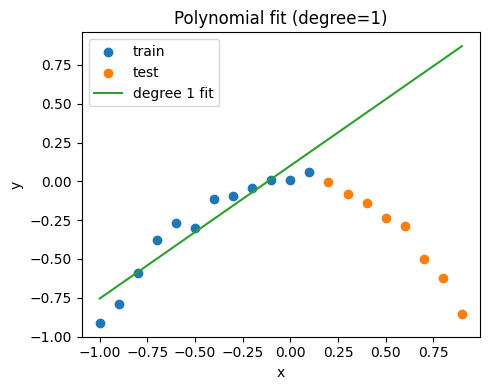

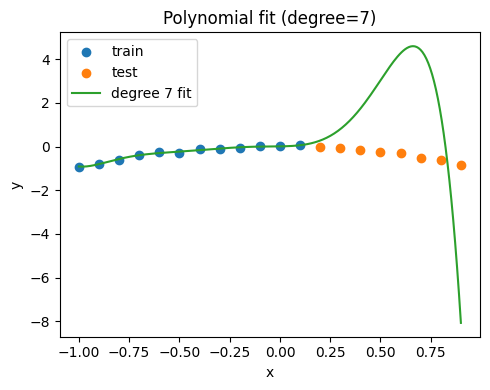

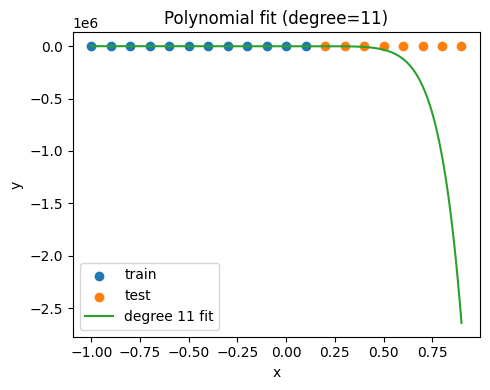

In [7]:
# To-Do: visualize degrees 1, 7, and 11
plot_polyfit(1)
plot_polyfit(7)
plot_polyfit(11)


**Learning point**  
Higher degree polynomials can perfectly fit training data yet fail to generalize. This is overfitting. You should always check test error, not just training error.

![image.png](https://github.com/user-attachments/assets/cdfb495c-066a-4efb-a361-f4b9d4ade35c)

## 🌟 Exercise 5: Cross-Validation to Find the Optimal Degree

**As stated in the exercise**  
Objective: Use cross-validation to determine the best polynomial degree.  

Instructions: Loop degrees from 1 to 11. For each degree, compute the RMSE on the training and test sets. Store results in a list. Plot RMSE vs degree with a logarithmic y axis. Identify the degree minimizing test RMSE and confirm it matches the true model \(y=-x^2\).


In [8]:
# To-Do: compute RMSE per degree for train and test
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

degrees = range(1, 12)
rows = []  # each row: (degree, rmse_train, rmse_test)
for d in degrees:
    # fit on train
    poly = polynomial_fit(d)
    # evaluate on train and test
    rmse_train = rmse(y_train, poly(x_train))
    rmse_test = rmse(y_test, poly(x_test))
    # append to rows
    rows.append((d, rmse_train, rmse_test))

rows[:3]  # peek


[(1, np.float64(0.1002263344864799), np.float64(1.0240708833556866)),
 (2, np.float64(0.04114590494650985), np.float64(0.12578064282386534)),
 (3, np.float64(0.037336922311085964), np.float64(0.769651993080075))]

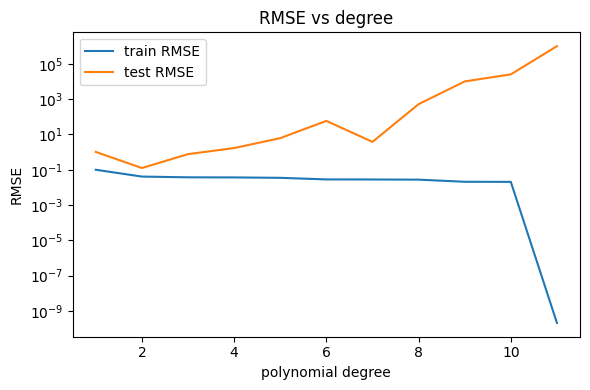

In [9]:
# Pre-filled: plotting RMSE curves (one figure, two curves)
degs = [r[0] for r in rows]
rmse_tr = [r[1] for r in rows]
rmse_te = [r[2] for r in rows]
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(degs, rmse_tr, label="train RMSE")
plt.plot(degs, rmse_te, label="test RMSE")
plt.yscale("log")
plt.xlabel("polynomial degree")
plt.ylabel("RMSE")
plt.title("RMSE vs degree")
plt.legend()
plt.tight_layout()
plt.show()


**To-Do answer**

The minimum test RMSE occurs at **degree 2**. This matches the true underlying model \(y = -x^2\), since a degree-2 polynomial is exactly expressive enough to capture that quadratic relationship without needing extra terms. Degrees below 2 **underfit** (high bias — the model is too simple to capture the curve), while degrees well above 2 **overfit** (high variance — the model starts chasing the Gaussian noise in the training points, and test error rises even though train error keeps falling). Degree 2 sits at the sweet spot of the bias–variance trade-off, generalizing best to unseen data.
